In [1]:
import numpy as np
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import scienceplots
plt.style.use(['science','no-latex'])

In [2]:
from util import LB_time,formation_time,bar_size_filter

In [ ]:
# visual check , barred from ellipse fitting, but unbarred.
TNG100visual =[466436, 502279, 408076, 121875, 383508, 499223, 488500, 265269,
       265268, 360510, 497220, 514127, 517199, 470617, 518236, 489054,
       540767, 125033, 495214, 429680, 393337, 269441, 376963, 499852,
       175245, 539284, 446612, 279709, 345251, 295079, 421032, 455857,
       474813, 476362, 181987, 406256, 273142, 499960, 297211,  96510,
       523008, 535817, 467212, 448269, 407321, 492825, 523035, 483113,
       492845, 367931, 508748, 439631, 535887, 210769, 498520, 523109,
       511858, 449910, 513402, 378749, 386429, 517503, 492425, 529804,
       510861, 128399, 128400, 314772, 336276, 510362, 427419, 477089,
       376739, 473004, 493491, 337845, 364480, 520649, 527306, 466387,
       494036, 502232, 500188, 131050, 526833]
TNG50visual=[63877,117254,117266,167405,198184,220600,264888,275549,294869,360925,443050,496789,499022,
 528836,531910,547546,553231,553837,566661,574615,575596,577125,582344,583745,587819,588647,590218,597141,
 598320,601997,605708,613006,617719,619081,619223,620463,621167,629266,630870,630975,632310,635905,642220,
 643642,652267]

obs20z_TNG100=np.array([ 0.56001306, -5.55693277])

In [ ]:
# read data
barTNG50 = h5py.File('./data/tng50-1_bar_size.hdf5','r')
barTNG100 = h5py.File('./data/tng100-1_bar_size.hdf5','r')

In [5]:
# get ID, mass, bar size, bar flag
TNG50_ID = barTNG50['gal_ID'][...]
TNG50_M30 = barTNG50['Snapshot_99']['stellar_mass'][...]
TNG50_barflag = barTNG50['Snapshot_99']['Ellipse_cut_0.6']['Barflag'][...]
TNG50_barlength = np.max([barTNG50['Snapshot_99']['Ellipse_cut_0.6']['R_bar'][...],
                          barTNG50['Snapshot_99']['Ellipse_cut_1.4']['R_bar'][...]],axis=0)
TNG50_barflag[np.isin(TNG50_ID,TNG50visual)]=0

TNG100_ID = barTNG100['gal_ID'][...]
TNG100_M30 = barTNG100['Snapshot_99']['stellar_mass'][...]
TNG100_barflag = barTNG100['Snapshot_99']['Ellipse_cut_1.4']['Barflag'][...]
TNG100_barlength =barTNG100['Snapshot_99']['Ellipse_cut_1.4']['R_bar'][...]
TNG100_barflag[np.isin(TNG100_ID,TNG100visual)]=0

In [6]:
# split into unbarred, short-bar, normal-bar

TNG50_barred_ID = TNG50_ID[(TNG50_barflag==1)]
TNG50_unbarred_ID = TNG50_ID[TNG50_barflag!=1]
TNG50_barred_M = TNG50_M30[(TNG50_barflag==1)]
TNG50_unbarred_M = TNG50_M30[TNG50_barflag!=1]


TNG50_normalbar_ID = TNG50_ID[(TNG50_barflag==1)&(
    np.log10(TNG50_barlength)>(obs20z_TNG100[0]*TNG50_M30+obs20z_TNG100[1]))]
TNG50_shortbar_ID = TNG50_ID[(TNG50_barflag==1)&(
    np.log10(TNG50_barlength)<(obs20z_TNG100[0]*TNG50_M30+obs20z_TNG100[1]))]
TNG50_normalbar_M = TNG50_M30[(TNG50_barflag==1)&(
    np.log10(TNG50_barlength)>(obs20z_TNG100[0]*TNG50_M30+obs20z_TNG100[1]))]
TNG50_shortbar_M = TNG50_M30[(TNG50_barflag==1)&(
    np.log10(TNG50_barlength)<(obs20z_TNG100[0]*TNG50_M30+obs20z_TNG100[1]))]

/tmp/ipykernel_194881/3425031434.py:10: RuntimeWarning: divide by zero encountered in log10
  np.log10(TNG50_barlength)>(obs20z_TNG100[0]*TNG50_M30+obs20z_TNG100[1]))]
/tmp/ipykernel_194881/3425031434.py:12: RuntimeWarning: divide by zero encountered in log10
  np.log10(TNG50_barlength)<(obs20z_TNG100[0]*TNG50_M30+obs20z_TNG100[1]))]
/tmp/ipykernel_194881/3425031434.py:14: RuntimeWarning: divide by zero encountered in log10
  np.log10(TNG50_barlength)>(obs20z_TNG100[0]*TNG50_M30+obs20z_TNG100[1]))]
/tmp/ipykernel_194881/3425031434.py:16: RuntimeWarning: divide by zero encountered in log10
  np.log10(TNG50_barlength)<(obs20z_TNG100[0]*TNG50_M30+obs20z_TNG100[1]))]


In [7]:
# sort by stellar mass
TNG50_normalbar_ID = TNG50_normalbar_ID[np.argsort(TNG50_normalbar_M)][::-1]
TNG50_shortbar_ID = TNG50_shortbar_ID[np.argsort(TNG50_shortbar_M)][::-1]
TNG50_barred_ID = TNG50_barred_ID[np.argsort(TNG50_barred_M)][::-1]
TNG50_unbarred_ID = TNG50_unbarred_ID[np.argsort(TNG50_unbarred_M)][::-1]

TNG50_normalbar_M = np.sort(TNG50_normalbar_M)[::-1]
TNG50_shortbar_M = np.sort(TNG50_shortbar_M)[::-1]
TNG50_barred_M = np.sort(TNG50_barred_M)[::-1]
TNG50_unbarred_M = np.sort(TNG50_unbarred_M)[::-1]

In [8]:
# same thing, for TNG100
TNG100_barred_ID = TNG100_ID[(TNG100_barflag==1)]
TNG100_unbarred_ID = TNG100_ID[TNG100_barflag!=1]
TNG100_barred_M = TNG100_M30[(TNG100_barflag==1)]
TNG100_unbarred_M = TNG100_M30[TNG100_barflag!=1]

TNG100_normalbar_ID = TNG100_ID[(TNG100_barflag==1)&(
    np.log10(TNG100_barlength)>(obs20z_TNG100[0]*TNG100_M30+obs20z_TNG100[1]))]
TNG100_shortbar_ID = TNG100_ID[(TNG100_barflag==1)&(
    np.log10(TNG100_barlength)<(obs20z_TNG100[0]*TNG100_M30+obs20z_TNG100[1]))]
TNG100_normalbar_M = TNG100_M30[(TNG100_barflag==1)&(
    np.log10(TNG100_barlength)>(obs20z_TNG100[0]*TNG100_M30+obs20z_TNG100[1]))]
TNG100_shortbar_M = TNG100_M30[(TNG100_barflag==1)&(
    np.log10(TNG100_barlength)<(obs20z_TNG100[0]*TNG100_M30+obs20z_TNG100[1]))]

/tmp/ipykernel_194881/1416843933.py:8: RuntimeWarning: divide by zero encountered in log10
  np.log10(TNG100_barlength)>(obs20z_TNG100[0]*TNG100_M30+obs20z_TNG100[1]))]
/tmp/ipykernel_194881/1416843933.py:10: RuntimeWarning: divide by zero encountered in log10
  np.log10(TNG100_barlength)<(obs20z_TNG100[0]*TNG100_M30+obs20z_TNG100[1]))]
/tmp/ipykernel_194881/1416843933.py:12: RuntimeWarning: divide by zero encountered in log10
  np.log10(TNG100_barlength)>(obs20z_TNG100[0]*TNG100_M30+obs20z_TNG100[1]))]
/tmp/ipykernel_194881/1416843933.py:14: RuntimeWarning: divide by zero encountered in log10
  np.log10(TNG100_barlength)<(obs20z_TNG100[0]*TNG100_M30+obs20z_TNG100[1]))]


In [9]:
TNG100_normalbar_ID = TNG100_normalbar_ID[np.argsort(TNG100_normalbar_M)][::-1]
TNG100_shortbar_ID = TNG100_shortbar_ID[np.argsort(TNG100_shortbar_M)][::-1]
TNG100_barred_ID = TNG100_barred_ID[np.argsort(TNG100_barred_M)][::-1]
TNG100_unbarred_ID = TNG100_unbarred_ID[np.argsort(TNG100_unbarred_M)][::-1]

TNG100_normalbar_M = np.sort(TNG100_normalbar_M)[::-1]
TNG100_shortbar_M = np.sort(TNG100_shortbar_M)[::-1]
TNG100_barred_M = np.sort(TNG100_barred_M)[::-1]
TNG100_unbarred_M = np.sort(TNG100_unbarred_M)[::-1]

In [10]:
# get bar size evolution, TNG50
TNG50_normalbar_bars=[]
TNG50_shortbar_bars=[]
TNG50_unbarred_bars=[]
for snap in np.arange(50,100)[::-1]:
    thisbar = []
    for i in TNG50_normalbar_ID:
        Rbar1 = (barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_0.6']['R_bar'][...][barTNG50['gal_ID'][...]==i][0]
                 if barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_0.6']['Barflag'][...][barTNG50['gal_ID'][...]==i]==1
                 else 0.)
        Rbar2 = (barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['R_bar'][...][barTNG50['gal_ID'][...]==i][0]
                 if barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['Barflag'][...][barTNG50['gal_ID'][...]==i]==1
                 else 0.)
        thisbar.append(np.max([Rbar1,Rbar2]))
        
    TNG50_normalbar_bars.append(thisbar)
    thisbar = []
    for i in TNG50_shortbar_ID:
        Rbar1 = (barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_0.6']['R_bar'][...][barTNG50['gal_ID'][...]==i][0]
                 if barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_0.6']['Barflag'][...][barTNG50['gal_ID'][...]==i]==1
                 else 0.)
        Rbar2 = (barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['R_bar'][...][barTNG50['gal_ID'][...]==i][0]
                 if barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['Barflag'][...][barTNG50['gal_ID'][...]==i]==1
                 else 0.)
        thisbar.append(np.max([Rbar1,Rbar2]))
        
    TNG50_shortbar_bars.append(thisbar)
    thisbar = []
    for i in TNG50_unbarred_ID:
        Rbar1 = (barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_0.6']['R_bar'][...][barTNG50['gal_ID'][...]==i][0]
                 if barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_0.6']['Barflag'][...][barTNG50['gal_ID'][...]==i]==1
                 else 0.)
        Rbar2 = (barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['R_bar'][...][barTNG50['gal_ID'][...]==i][0]
                 if barTNG50['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['Barflag'][...][barTNG50['gal_ID'][...]==i]==1
                 else 0.)
        thisbar.append(np.max([Rbar1,Rbar2]))
        
    TNG50_unbarred_bars.append(thisbar)

In [11]:
# get bar size evolution, TNG100
TNG100_normalbar_bars=[]
TNG100_shortbar_bars=[]
TNG100_unbarred_bars=[]
for snap in np.arange(50,100)[::-1]:
    thisbar = []
    for i in TNG100_normalbar_ID:
        Rbar2 = (barTNG100['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['R_bar'][...][barTNG100['gal_ID'][...]==i][0]
                 if barTNG100['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['Barflag'][...][barTNG100['gal_ID'][...]==i]==1
                 else 0.)
        thisbar.append(Rbar2)
        
    TNG100_normalbar_bars.append(thisbar)
    thisbar = []
    for i in TNG100_shortbar_ID:
        Rbar2 = (barTNG100['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['R_bar'][...][barTNG100['gal_ID'][...]==i][0]
                 if barTNG100['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['Barflag'][...][barTNG100['gal_ID'][...]==i]==1
                 else 0.)
        thisbar.append(Rbar2)
        
    TNG100_shortbar_bars.append(thisbar)
    thisbar = []
    for i in TNG100_unbarred_ID:
        Rbar2 = (barTNG100['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['R_bar'][...][barTNG100['gal_ID'][...]==i][0]
                 if barTNG100['Snapshot_'+str(snap)]['Ellipse_cut_1.4']['Barflag'][...][barTNG100['gal_ID'][...]==i]==1
                 else 0.)
        thisbar.append(Rbar2)
        
    TNG100_unbarred_bars.append(thisbar)

In [12]:
# filter, remove short lived bar, 
TNG50_R_N=np.array(TNG50_normalbar_bars).T
TNG50_R_S=np.array(TNG50_shortbar_bars).T
TNG50_R_U=np.array(TNG50_unbarred_bars).T

New_Rn=[]
for i in range(len(TNG50_R_N)):
    Rfil=bar_size_filter(TNG50_R_N[i],4)
    New_Rn.append(Rfil)
TNG50_R_N=np.array(New_Rn)
New_Rn=[]
for i in range(len(TNG50_R_S)):
    Rfil=bar_size_filter(TNG50_R_S[i],4)
    New_Rn.append(Rfil)
TNG50_R_S=np.array(New_Rn)
New_Rn=[]
for i in range(len(TNG50_R_U)):
    Rfil=bar_size_filter(TNG50_R_U[i],4)
    New_Rn.append(Rfil)
TNG50_R_U=np.array(New_Rn)

In [13]:
# filter, remove short lived bar
TNG100_R_N=np.array(TNG100_normalbar_bars).T
TNG100_R_S=np.array(TNG100_shortbar_bars).T
TNG100_R_U=np.array(TNG100_unbarred_bars).T

New_Rn=[]
for i in range(len(TNG100_R_N)):
    Rfil=bar_size_filter(TNG100_R_N[i],4)
    New_Rn.append(Rfil)
TNG100_R_N=np.array(New_Rn)
New_Rn=[]
for i in range(len(TNG100_R_S)):
    Rfil=bar_size_filter(TNG100_R_S[i],4)
    New_Rn.append(Rfil)
TNG100_R_S=np.array(New_Rn)
New_Rn=[]
for i in range(len(TNG100_R_U)):
    Rfil=bar_size_filter(TNG100_R_U[i],4)
    New_Rn.append(Rfil)
TNG100_R_U=np.array(New_Rn)

In [ ]:
# get corresponding mass, trans num to mass, because all galaxies are sorted by stellar mass
m_n=[10.0,10.1,10.2,10.3,10.4,10.5,10.6,10.9][::-1]
tickn=[len(TNG50_normalbar_M[TNG50_normalbar_M>i]) for i in m_n]
m_s = [10.0,10.2,10.3,10.4,10.5,10.6,10.7,10.8,10.9,11.0][::-1]
ticks=[len(TNG50_shortbar_M[TNG50_shortbar_M>i]) for i in m_s]
m_u=[10.0,10.1,10.2,10.3,10.4,10.5,10.6,11.0][::-1]
ticku=[len(TNG50_unbarred_M[TNG50_unbarred_M>i]) for i in m_u]

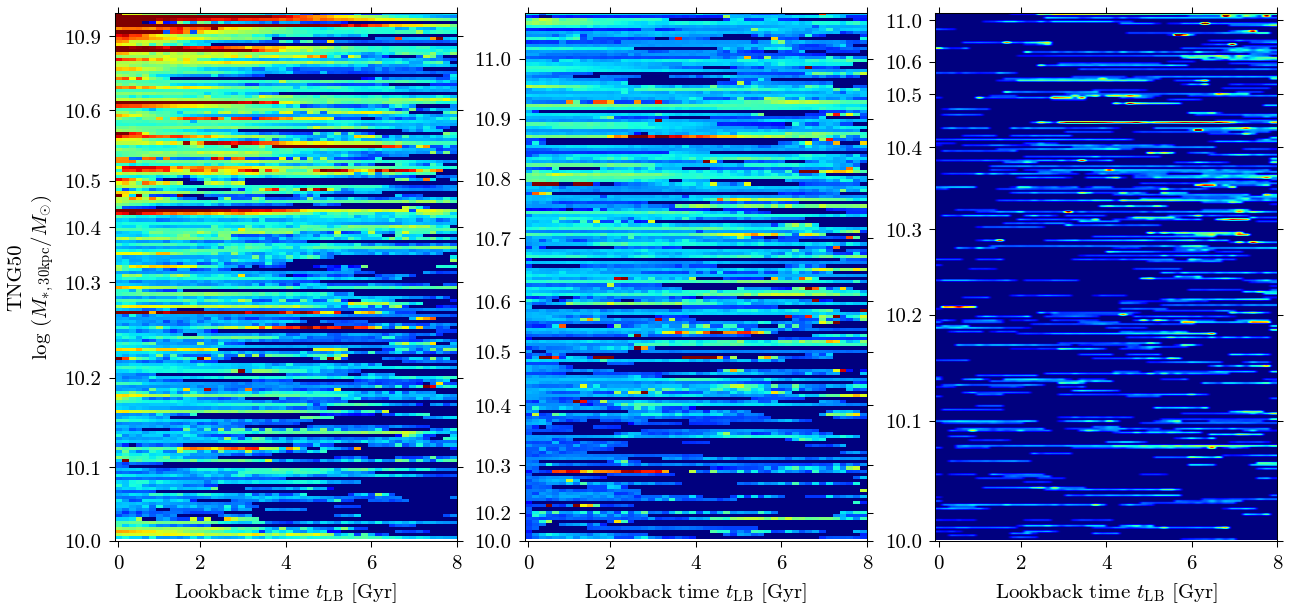

In [15]:
fig, axs=plt.subplots(1,3,figsize=(10,5),dpi=150,)
aspectn=0.45
axs[0].imshow(TNG50_R_N,aspect=aspectn,vmin=0,vmax=6,cmap=plt.cm.jet,)
#axs[0].set_title(label='Normal-bar')
axs[0].set_yticks(tickn)
axs[0].set_yticklabels(m_n)
axs[0].set_ylabel('TNG50'+'\n'+'log $(M_\mathrm{*,30kpc}/M_{\odot})$')
axs[0].set_xticks([0,12,24.5,37,49.5])
axs[0].set_xticklabels([0,2,4,6,8])
axs[0].set_xlabel('Lookback time $t_\mathrm{LB}$ [Gyr]')
fi=axs[1].imshow(TNG50_R_S,aspect=aspectn*len(TNG50_R_N)/len(TNG50_R_S),vmin=0,vmax=6,cmap=plt.cm.jet)
#axs[1].set_title(label='Short-bar')
axs[1].set_yticks(ticks)
axs[1].set_yticklabels(m_s)
axs[1].set_xticks([0,12,24.5,37,49.5])
axs[1].set_xticklabels([0,2,4,6,8])
axs[1].set_xlabel('Lookback time $t_\mathrm{LB}$ [Gyr]')

axs[2].imshow(TNG50_R_U,aspect=aspectn*len(TNG50_R_N)/len(TNG50_R_U),vmin=0,vmax=6,cmap=plt.cm.jet)
#axs[2].set_title(label='Unbarred')
axs[2].set_yticks(ticku)
axs[2].set_yticklabels(m_u)
axs[2].set_xticks([0,12,24.5,37,49.5])
axs[2].set_xticklabels([0,2,4,6,8])
axs[2].set_xlabel('Lookback time $t_\mathrm{LB}$ [Gyr]')
for i in axs:
    i.set_yticks([],minor=True)
    i.set_xticks([],minor=True)
    i.tick_params(axis='both',which='both',direction='out')

plt.savefig('./showTNG50barlength_bymass.png',bbox_inches='tight')

In [16]:
m_n=[10.4,10.5,10.6,10.7,10.8,10.9,11.0][::-1]
tickn=[len(TNG100_normalbar_M[TNG100_normalbar_M>i]) for i in m_n]
m_s = [10.4,10.5,10.6,10.7,10.8,10.9,11.0][::-1]
ticks=[len(TNG100_shortbar_M[TNG100_shortbar_M>i]) for i in m_s]
m_u=[10.4,10.5,10.6,10.7,10.8,10.9,11.0][::-1]
ticku=[len(TNG100_unbarred_M[TNG100_unbarred_M>i]) for i in m_u]

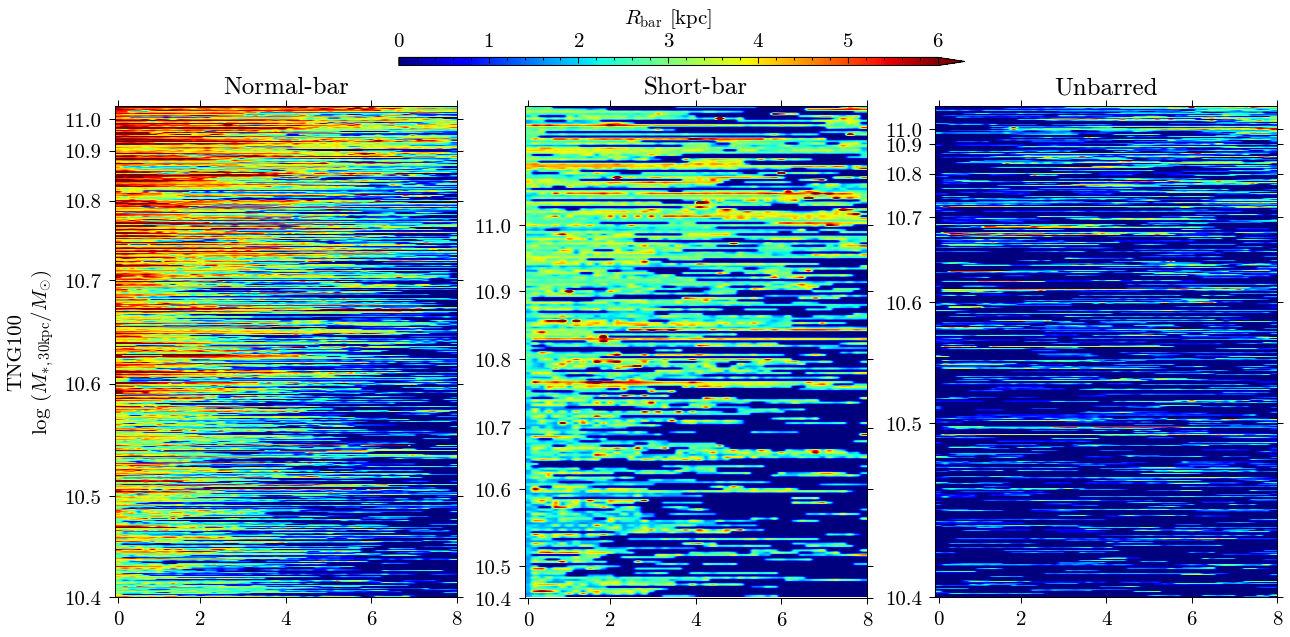

In [17]:
fig, axs=plt.subplots(1,3,figsize=(10,7),dpi=150,)
aspectn=0.1
axs[0].imshow(TNG100_R_N,aspect=aspectn,vmin=0,vmax=6,cmap=plt.cm.jet,)
axs[0].set_title(label='Normal-bar')
axs[0].set_yticks(tickn)
axs[0].set_yticklabels(m_n)
axs[0].set_ylabel('TNG100'+'\n'+'log $(M_\mathrm{*,30kpc}/M_{\odot})$')
axs[0].set_xticks([0,12,24.5,37,49.5])
axs[0].set_xticklabels([0,2,4,6,8])
#axs[0].set_xlabel('Lookback time $t_\mathrm{LB}$ [Gyr]')
fi=axs[1].imshow(TNG100_R_S,aspect=aspectn*len(TNG100_R_N)/len(TNG100_R_S),vmin=0,vmax=6,cmap=plt.cm.jet)
axs[1].set_title(label='Short-bar')
axs[1].set_yticks(ticks)

axs[1].set_yticklabels(m_s)
axs[1].set_xticks([0,12,24.5,37,49.5])
axs[1].set_xticklabels([0,2,4,6,8])
#axs[1].set_xlabel('Lookback time $t_\mathrm{LB}$ [Gyr]')

axs[2].imshow(TNG100_R_U,aspect=aspectn*len(TNG100_R_N)/len(TNG100_R_U),vmin=0,vmax=6,cmap=plt.cm.jet)
axs[2].set_title(label='Unbarred')
axs[2].set_yticks(ticku)
axs[2].set_yticklabels(m_u)
axs[2].set_xticks([0,12,24.5,37,49.5])
axs[2].set_xticklabels([0,2,4,6,8])
#axs[2].set_xlabel('Lookback time $t_\mathrm{LB}$ [Gyr]')
for i in axs:
    i.set_yticks([],minor=True)
    i.set_xticks([],minor=True)
    i.tick_params(axis='both',which='both',direction='out')
fig.colorbar(fi,ax=axs[0:3],fraction=0.01,orientation='horizontal',extend='max',label='$R_\mathrm{bar}$ [kpc]',
             location='top',aspect=70)
#fig.suptitle('TNG100')
plt.savefig('./showTNG100barlength_bymass.png',bbox_inches='tight')